# Test and compare several magnification definitions

This notebook visualizes the outputs fo test_magnification_grid.py

In [75]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
%matplotlib inline

df = pd.read_csv('source_mags_03.csv',delim_whitespace=True)
df.head()

,x,y,xi,yi,mus_true,area_ratio,flux_ratio,mean_mu,median_mu,wfl_mu,mu_point
0,-10.000,-10.0,-18.461304,-18.461304,4.320167,4.360996,4.353671,4.344323,4.333677,4.350594,4.361746
1,-9.375,-10.0,-16.922785,-19.187475,4.457563,4.456790,4.482568,4.484427,4.476132,4.490159,4.502372
2,-8.750,-10.0,-15.283654,-19.916903,4.494289,4.517598,4.523464,4.525436,4.521006,4.527090,4.537422
3,-8.125,-10.0,-13.571859,-20.613827,4.416963,4.421811,4.436764,4.450708,4.445057,4.446354,4.452284
4,-7.500,-10.0,-11.823760,-21.244965,4.244028,4.288382,4.267004,4.277257,4.267235,4.268166,4.269479


## source and image positions

/Users/massimo/anaconda3/envs/python3/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
/Users/massimo/anaconda3/envs/python3/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


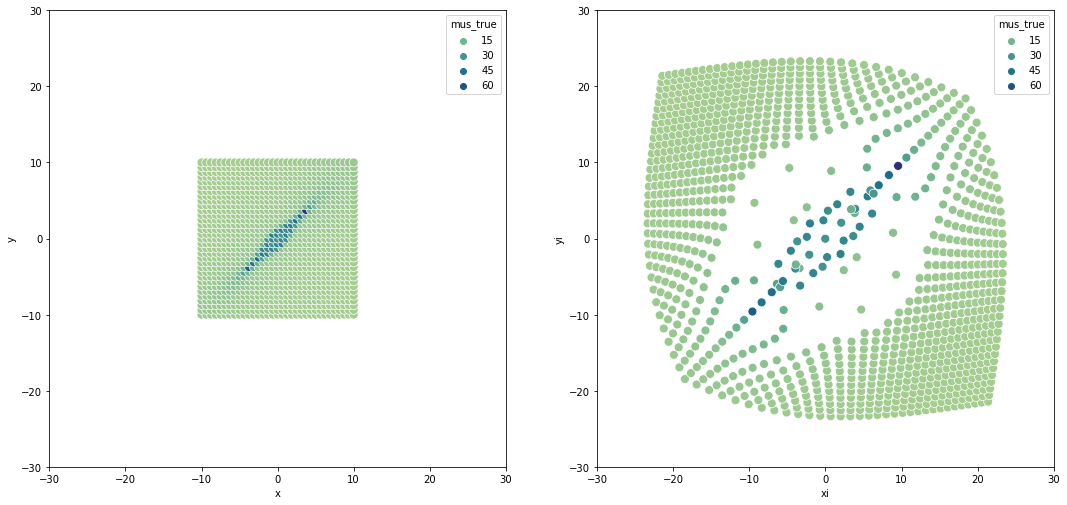

In [76]:
fig,ax=plt.subplots(1,2,figsize=(18,10))
sns.scatterplot('x','y',hue='mus_true',data=df,ax=ax[0],palette='crest',s=80)
sns.scatterplot('xi','yi',hue='mus_true',data=df,ax=ax[1],palette='crest',s=80)
#ax[0].plot(df.x,df.y,'o',color='blue')
#ax[1].plot(df.xi,df.yi,'o',color='blue')
for i in range(2):
    ax[i].set_xlim([-30,30])
    ax[i].set_ylim([-30,30])
    ax[i].set_aspect('equal')

## magnification definitions

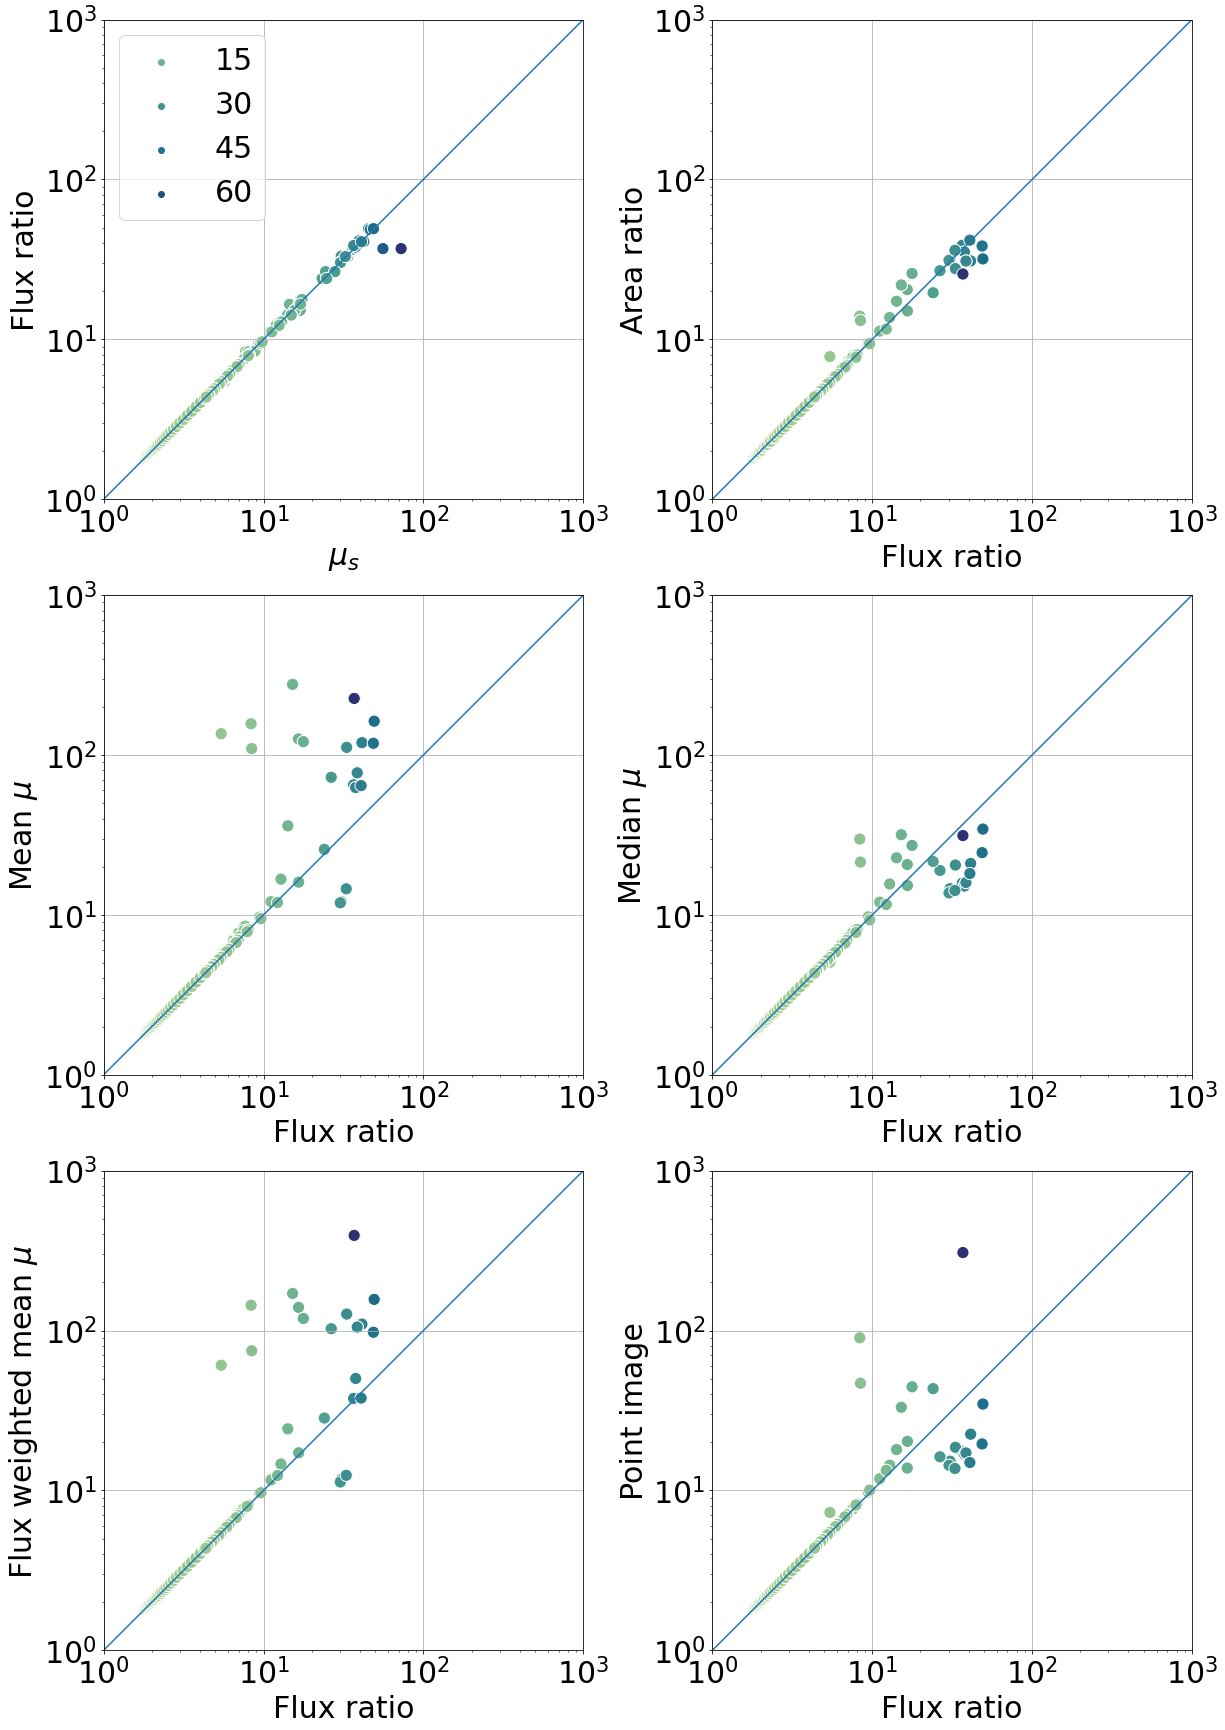

In [77]:
fig,ax = plt.subplots(3,2,figsize=(20,30))
sns.scatterplot(x='mus_true',y='flux_ratio',hue='mus_true',data=df,ax=ax[0,0],palette='crest',s=150)
ax[0,0].set_xlabel(r'$\mu_s$',fontsize=30)
ax[0,0].set_ylabel(r'Flux ratio',fontsize=30)

sns.scatterplot(x='flux_ratio',y='area_ratio',hue='mus_true',data=df,ax=ax[0,1],palette='crest',s=150,legend = False)
ax[0,1].set_xlabel(r'Flux ratio',fontsize=30)
ax[0,1].set_ylabel(r'Area ratio',fontsize=30)

sns.scatterplot(x='flux_ratio',y='mean_mu',hue='mus_true',data=df,ax=ax[1,0],palette='crest',s=150,legend = False)
ax[1,0].set_xlabel(r'Flux ratio',fontsize=30)
ax[1,0].set_ylabel(r'Mean $\mu$',fontsize=30)

sns.scatterplot(x='flux_ratio',y='median_mu',hue='mus_true',data=df,ax=ax[1,1],palette='crest',s=150,legend = False)
ax[1,1].set_xlabel(r'Flux ratio',fontsize=30)
ax[1,1].set_ylabel(r'Median $\mu$',fontsize=30)

sns.scatterplot(x='flux_ratio',y='wfl_mu',hue='mus_true',data=df,ax=ax[2,0],palette='crest',s=150,legend = False)
ax[2,0].set_xlabel(r'Flux ratio',fontsize=30)
ax[2,0].set_ylabel(r'Flux weighted mean $\mu$',fontsize=30)

sns.scatterplot(x='flux_ratio',y='mu_point',hue='mus_true',data=df,ax=ax[2,1],palette='crest',s=150,legend = False)
ax[2,1].set_xlabel(r'Flux ratio',fontsize=30)
ax[2,1].set_ylabel(r'Point image',fontsize=30)

for i in range(3):
    for j in range(2):
        ax[i,j].plot([1,1000],[1,1000])
        ax[i,j].set_xlim([1,1000])
        ax[i,j].set_ylim([1,1000])
        ax[i,j].set_xscale('log')
        ax[i,j].set_yscale('log')
        ax[i,j].xaxis.set_tick_params(labelsize=30)
        ax[i,j].yaxis.set_tick_params(labelsize=30)
        ax[i,j].set_aspect('equal')
        ax[i,j].grid(True)
ax[0,0].legend(fontsize=30)

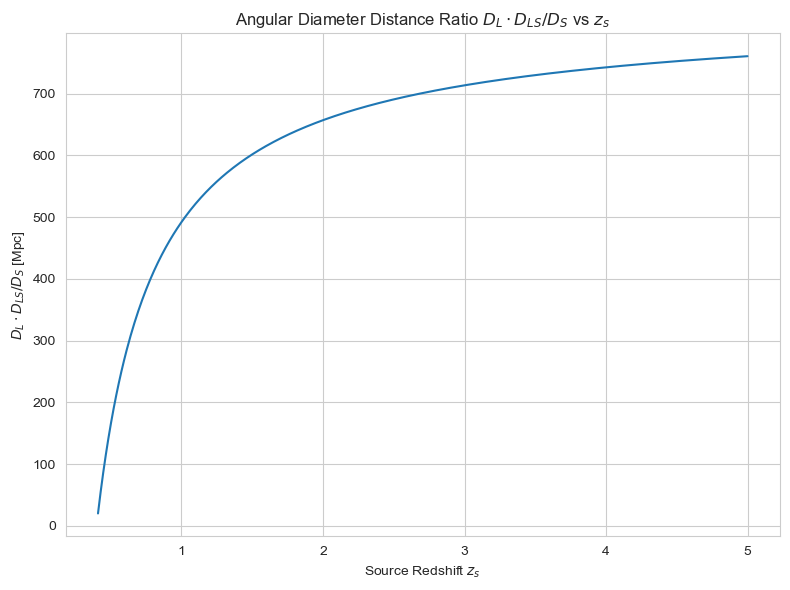

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM

# Define cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.7)
# Lens redshift
z_lens = 0.4
# Source redshift range
z_source = np.linspace(z_lens + 0.01, 5.0, 500)

def dlensing(z_lens,z_source):
    # Compute distances
    D_L = cosmo.angular_diameter_distance(z_lens).value  # in Mpc
    D_S = cosmo.angular_diameter_distance(z_source).value  # in Mpc
    D_LS = cosmo.angular_diameter_distance_z1z2(z_lens, z_source).value  # in Mpc

    # Compute D_L * D_LS / D_S
    dl_dls_ds_ratio = D_L * D_LS / D_S
    return dl_dls_ds_ratio

dl = dlensing(z_lens, z_source)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(z_source, dl)
plt.xlabel("Source Redshift $z_s$")
plt.ylabel(r"$D_L \cdot D_{LS} / D_S$ [Mpc]")
plt.title(r"Angular Diameter Distance Ratio $D_L \cdot D_{LS} / D_S$ vs $z_s$")
plt.grid(True)
plt.tight_layout()
plt.show()

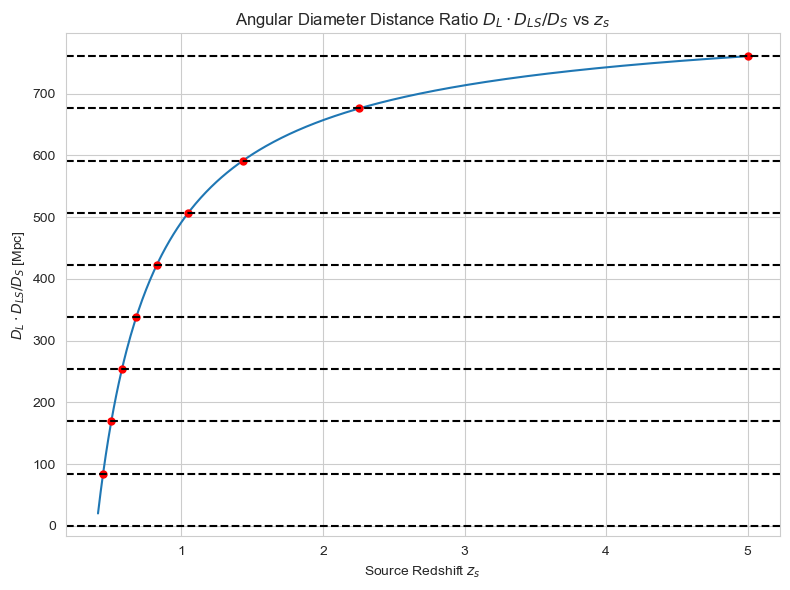

In [9]:
from scipy.interpolate import interp1d
# generate n_planes values of dl
def generateSrcPlanesDL(z_lens, z_source_max, n_planes=100):
    dl_max = dlensing(z_lens, z_source_max)
    zs_arr = np.linspace(z_lens + 0.01, z_source_max, 1000)
    dl_dls_ds = dlensing(z_lens, zs_arr)

    interp_func = interp1d(dl_dls_ds, zs_arr, bounds_error=False, fill_value=np.nan)
    dl_arr_equisp = np.linspace(0, dl_max, n_planes)
    z_planes = interp_func(dl_arr_equisp)
    return z_planes, dl_arr_equisp

z_planes, dl_arr_equisp = generateSrcPlanesDL(z_lens, 5.0, n_planes=10)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(z_source, dl)
plt.plot(z_planes, dl_arr_equisp, 'o', color='red', markersize=5, label='Equispaced planes')
for i in range(len(dl_arr_equisp)):
    plt.axhline(dl_arr_equisp[i], color='k', linestyle='--')
plt.xlabel("Source Redshift $z_s$")
plt.ylabel(r"$D_L \cdot D_{LS} / D_S$ [Mpc]")
plt.title(r"Angular Diameter Distance Ratio $D_L \cdot D_{LS} / D_S$ vs $z_s$")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
a